In [1]:
import os
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

from preprocessors import (
    ToGrayscale,
    NormalizePolarity,
    NormalizeContrast,
    BinarizeNormalize,
)

In [2]:
def read_bgr(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return img

def bgr_to_rgb(img):
    if len(img.shape) == 2:
        return img
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def show_image(img, title="", figsize=(10, 4)):
    plt.figure(figsize=figsize)
    if len(img.shape) == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(bgr_to_rgb(img))
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_grid(images, titles, cols=2, figsize=(14, 10)):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)

    for i, (img, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(rows, cols, i)
        if len(img.shape) == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(bgr_to_rgb(img))
        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

def apply_pipeline(image, preprocessors, label=""):
    data = (image.copy(), label)
    for proc in preprocessors:
        data = proc(data)
    return data[0]

In [57]:
image_dir = Path(r"D:\User\img_samples")
image_paths = sorted([p for p in image_dir.iterdir() ])

len(image_paths), image_paths[:50]

(34,
 [WindowsPath('D:/User/img_samples/1_cropped_01'),
  WindowsPath('D:/User/img_samples/1_cropped_02'),
  WindowsPath('D:/User/img_samples/1_cropped_03'),
  WindowsPath('D:/User/img_samples/1_cropped_04'),
  WindowsPath('D:/User/img_samples/1_cropped_05'),
  WindowsPath('D:/User/img_samples/1_cropped_06'),
  WindowsPath('D:/User/img_samples/1_cropped_07'),
  WindowsPath('D:/User/img_samples/1_cropped_08'),
  WindowsPath('D:/User/img_samples/1_cropped_09'),
  WindowsPath('D:/User/img_samples/1_cropped_10'),
  WindowsPath('D:/User/img_samples/1_cropped_11'),
  WindowsPath('D:/User/img_samples/1_cropped_12'),
  WindowsPath('D:/User/img_samples/1_cropped_13'),
  WindowsPath('D:/User/img_samples/1_cropped_14'),
  WindowsPath('D:/User/img_samples/1_cropped_15'),
  WindowsPath('D:/User/img_samples/AHTD3A0001_Para2_3'),
  WindowsPath('D:/User/img_samples/AHTD3A0001_Para2_4'),
  WindowsPath('D:/User/img_samples/AHTD3A0001_Para3_1'),
  WindowsPath('D:/User/img_samples/AHTD3A0001_Para3_2'),
  

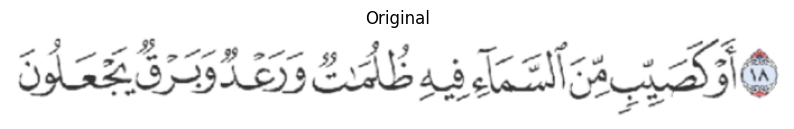

In [60]:
img = read_bgr(image_paths[21])
show_image(img, "Original")

In [10]:
pipeline_a = [
    ToGrayscale(strength=1.0, keep_3ch=True),
    NormalizePolarity(target="dark_on_light", mode="auto"),
    NormalizeContrast(method="clahe", clip_limit=3.0, tile_grid_size=(8, 8)),
]

In [11]:
pipeline_b = [
    ToGrayscale(strength=1.0, keep_3ch=True),
    NormalizePolarity(target="dark_on_light", mode="auto"),
    NormalizeContrast(method="clahe", clip_limit=3.0, tile_grid_size=(8, 8)),
    BinarizeNormalize(
        method="adaptive_gaussian",
        mode="soft",
        block_size=21,
        C=10,
        threshold=160,
        keep_3ch=True,
    ),
]

In [50]:
pipeline_c = [
    ToGrayscale(strength=1.0, keep_3ch=True),
    NormalizePolarity(target="dark_on_light", mode="auto"),
    NormalizeContrast(method="clahe", clip_limit=3.0, tile_grid_size=(8, 8)),
    BinarizeNormalize(
        method="otsu",
        mode="hard",
        block_size=21,
        C=10,
        threshold=160,
        keep_3ch=True,
    ),
]

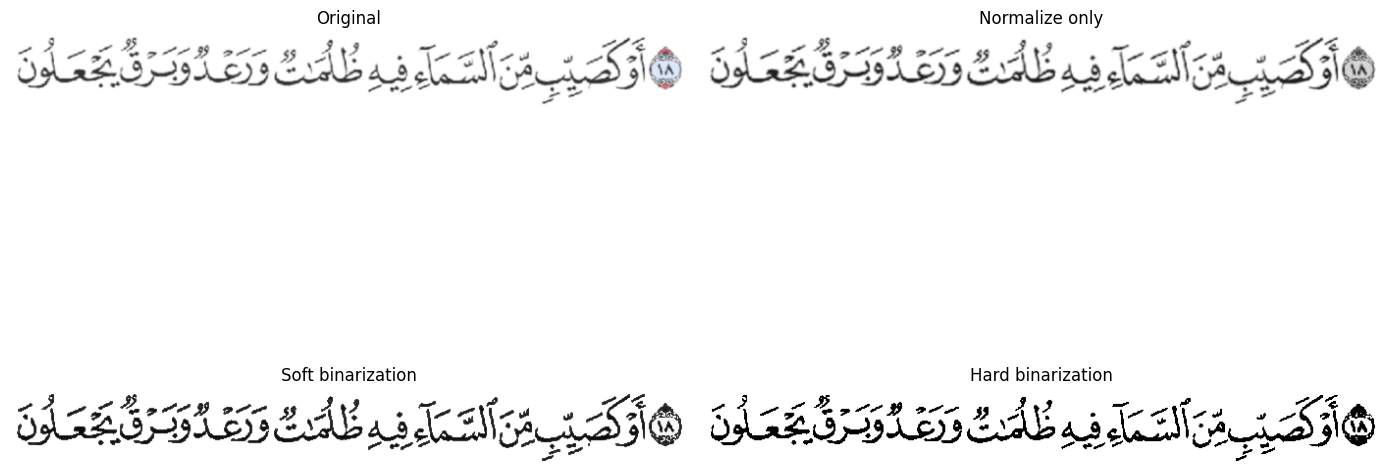

In [61]:
out_a = apply_pipeline(img, pipeline_a)
out_b = apply_pipeline(img, pipeline_b)
out_c = apply_pipeline(img, pipeline_c)

show_grid(
    [img, out_a, out_b, out_c],
    ["Original", "Normalize only", "Soft binarization", "Hard binarization"],
    cols=2,
    figsize=(14, 10),
)